# Clasificación de ventanas de tiempo -- PRINTER L1

Agrupa cada hora de PRINTER L1 en un estado operativo: `sin_datos`,
`detenida`, `comm_error`, `arrancando`, `deteniéndose`,
`producción_lenta/normal/rápida`.

**Enfoque**: no tenemos datos etiquetados a mano, así que en vez de forzar
un clasificador supervisado desde el inicio, este notebook combina dos
cosas:

1. **Reglas deterministas** para los estados que ya podemos determinar con
   certeza sin aprendizaje automático (mismo criterio que
   `functions/hourly_production_report` y `functions/timeseries_anomaly_detector`
   ya usan en producción): `comm_error` (lecturas negativas -- el sensor
   perdió comunicación, confirmado como hallazgo real esta sesión),
   `sin_datos` (la hora no tiene ningún datapoint) y `detenida` (hay datos,
   pero el delta de producción es exactamente 0).
2. **Clustering no supervisado (KMeans)** únicamente sobre las horas que
   quedan -- las que sí tuvieron producción real -- para separar
   `producción_lenta/normal/rápida`, más una regla simple de asimetría
   primera-mitad-vs-segunda-mitad de la hora para detectar `arrancando` /
   `deteniéndose`.

Los gráficos al final son la validación: se puede ver directamente si los
estados detectados tienen sentido frente a los datos crudos.


## 1. Cargar los datos crudos

Datos ya descargados de CDF (ver sesión) para los 3 contadores de PRINTER_L1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

DATA_DIR = "../data_exports/PRINTER_L1"
SIGNALS = {
    "produccion": "produccion_PRINTER_L1_PROD_ACT_DISP.csv",
    "retract": "retract_PRINTER_L1_RETRACT_ACT_DISP.csv",
    "blow_off": "blow_off_PRINTER_L1_LAT_SOP_ACT_DISP.csv",
}

def load_signal(fname):
    df = pd.read_csv(f"{DATA_DIR}/{fname}", index_col=0, parse_dates=True)
    s = df[df.columns[0]].rename("value")
    if s.index.tz is None:
        s.index = s.index.tz_localize("UTC")
    return s.tz_convert("Etc/GMT+4")  # local GMT-4, matching the rest of the project

signals = {name: load_signal(fname) for name, fname in SIGNALS.items()}
for name, s in signals.items():
    print(f"{name}: {len(s):,} datapoints, {s.index.min()} -> {s.index.max()}")


produccion: 8,546 datapoints, 2026-07-21 21:18:56.637000-04:00 -> 2026-08-22 23:31:31.579000-04:00
retract: 8,546 datapoints, 2026-07-21 21:18:56.637000-04:00 -> 2026-08-22 23:31:31.579000-04:00
blow_off: 8,546 datapoints, 2026-07-21 21:18:56.637000-04:00 -> 2026-08-22 23:31:31.579000-04:00


## 2. Ingeniería de features por hora

Para cada hora se calcula, por cada una de las 3 señales:

- `n_points` / `n_negative`: cuántas muestras hay, y cuántas son lecturas
  negativas (comunicación perdida).
- `delta`: el incremento real del contador en esa hora -- **mismo cálculo
  reset-aware que `calculate_hourly_counter_delta()`** en
  `hourly_production_report/handler.py`: descarta lecturas negativas antes
  de todo (fix de esta misma sesión), trata una caída a ~0 como reset real,
  y excluye cualquier otra caída como ruido.
- `delta_first_half` / `delta_second_half`: el mismo delta pero calculado
  por separado para cada mitad de la hora -- necesario para distinguir
  "arrancando"/"deteniéndose" de una hora estable, incluso a granularidad
  horaria.
- `std_step` / `max_step`: variabilidad del incremento entre muestras
  consecutivas.


In [2]:
RESET_TO_ZERO_EPS = 1.0

def reset_aware_delta(values: np.ndarray):
    values = values[values >= 0]  # drop comm-error negative readings
    if len(values) < 2:
        return 0.0
    delta = 0.0
    for i in range(1, len(values)):
        prev, curr = values[i - 1], values[i]
        step = curr - prev
        if step < 0:
            if curr < RESET_TO_ZERO_EPS:
                delta += curr  # genuine reset
            # else: noise, excluded
        else:
            delta += step
    return delta

def hourly_features_for_signal(s, hour_start, hour_end, prefix):
    window = s[(s.index >= hour_start) & (s.index < hour_end)]
    raw = window.values.astype(float)
    mid = hour_start + (hour_end - hour_start) / 2
    d1 = reset_aware_delta(window[window.index < mid].values.astype(float))
    d2 = reset_aware_delta(window[window.index >= mid].values.astype(float))
    pos = raw[raw >= 0]
    steps = np.diff(pos) if len(pos) > 1 else np.array([0.0])
    return {
        f"{prefix}_n_points": len(raw),
        f"{prefix}_n_negative": int((raw < 0).sum()),
        f"{prefix}_delta": reset_aware_delta(raw),
        f"{prefix}_delta_first_half": d1,
        f"{prefix}_delta_second_half": d2,
        f"{prefix}_std_step": float(np.std(steps)) if len(steps) else 0.0,
        f"{prefix}_max_step": float(np.max(steps)) if len(steps) else 0.0,
    }

all_index = pd.concat(list(signals.values())).index
hour_starts = pd.date_range(all_index.min().floor("h"), all_index.max().ceil("h"), freq="1h", inclusive="left")

rows = []
for hs in hour_starts:
    he = hs + pd.Timedelta(hours=1)
    row = {"hour_start": hs}
    for name, s in signals.items():
        row.update(hourly_features_for_signal(s, hs, he, name))
    rows.append(row)

features_df = pd.DataFrame(rows).set_index("hour_start")
print(f"{len(features_df)} horas, {features_df.shape[1]} features")
features_df[["produccion_delta", "produccion_n_points", "produccion_n_negative"]].describe()


C:\Users\sanch\AppData\Local\Temp\ipykernel_20768\3699538897.py:42: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  he = hs + pd.Timedelta(hours=1)


771 horas, 21 features


,produccion_delta,produccion_n_points,produccion_n_negative
count,771.000000,771.000000,771.000000
mean,3649.481193,11.084306,0.083009
std,11321.132132,30.393555,0.878818
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,58918.000000,120.000000,13.000000


## 3. Estados deterministas (sin ML)

Estos tres estados se pueden determinar con certeza por regla directa --
no tiene sentido pedirle a un clustering que "descubra" algo que ya
sabemos con precisión:


In [3]:
neg_cols = [c for c in features_df.columns if c.endswith("_n_negative")]
has_comm_error = (features_df[neg_cols] > 0).any(axis=1)
has_no_data = features_df["produccion_n_points"] == 0
is_stopped = (~has_comm_error) & (~has_no_data) & (features_df["produccion_delta"] == 0)

state = pd.Series("active", index=features_df.index)
state[is_stopped] = "detenida"
state[has_no_data] = "sin_datos"
state[has_comm_error] = "comm_error"  # se evalua al final: tiene prioridad

print(state.value_counts())


sin_datos     672
active         80
detenida       10
comm_error      9
Name: count, dtype: int64


## 4. Clustering (KMeans) sobre las horas activas

Solo las 80 horas con producción real necesitan clustering.

**Primer intento (revisado):** se agruparon con `produccion_delta`,
`std_step` y `max_step` juntos. El resultado tenía sentido en silhouette
score, pero al ordenar las horas por velocidad real, las etiquetas
quedaban entremezcladas -- una hora de 24,428 salía "normal" pero una de
25,830 (más rápida) salía "lenta". El problema: `std_step`/`max_step`
miden qué tan irregular es el ritmo dentro de la hora (ráfagas vs. ritmo
constante), no la velocidad -- dos horas con la misma producción total
pero distinta regularidad terminaban en clusters distintos.

**Fix:** clasificar velocidad usando *solo* `produccion_delta`. En una
sola dimensión, KMeans siempre produce grupos ordenados (sin traslape),
que es exactamente lo que se espera de "lenta/normal/rápida".


In [4]:
active_df = features_df.loc[state[state == "active"].index].copy()
X_scaled = StandardScaler().fit_transform(active_df[["produccion_delta"]].values)

for k in range(2, 6):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)
    print(f"k={k}: silhouette={silhouette_score(X_scaled, labels):.3f}, tamanos={np.bincount(labels)}")


k=2: silhouette=0.567, tamanos=[28 52]
k=3: silhouette=0.539, tamanos=[35 14 31]
k=4: silhouette=0.542, tamanos=[19 22 30  9]
k=5: silhouette=0.548, tamanos=[23 23  9 18  7]


In [5]:
km = KMeans(n_clusters=3, n_init=10, random_state=42)
raw_labels = km.fit_predict(X_scaled)

cluster_means = pd.Series(active_df["produccion_delta"].values).groupby(raw_labels).mean().sort_values()
order = {old: new for new, old in enumerate(cluster_means.index)}
label_names = {0: "produccion_lenta", 1: "produccion_normal", 2: "produccion_rapida"}
active_df["speed_cluster"] = [label_names[order[l]] for l in raw_labels]

print(active_df["speed_cluster"].value_counts())


speed_cluster
produccion_normal    35
produccion_rapida    31
produccion_lenta     14
Name: count, dtype: int64


## 5. Sin clase de transición

Se intentó una regla de arrancando/deteniéndose basada en la asimetría entre la primera y segunda mitad de la hora, pero no dio un resultado confiable -- las horas de transición real quedaban indistinguibles de ruido normal dentro de la hora. Esas horas se clasifican en su lugar según su velocidad real (`produccion_lenta`/`normal`/`rapida`), igual que cualquier otra hora activa.

In [6]:
state.loc[active_df.index] = active_df["speed_cluster"]
features_df["state"] = state

print(state.value_counts())


sin_datos            672
produccion_normal     35
produccion_rapida     31
produccion_lenta      14
detenida              10
comm_error             9
Name: count, dtype: int64


## 6. Validación visual

La prueba real: ¿tienen sentido los estados frente a los datos crudos?

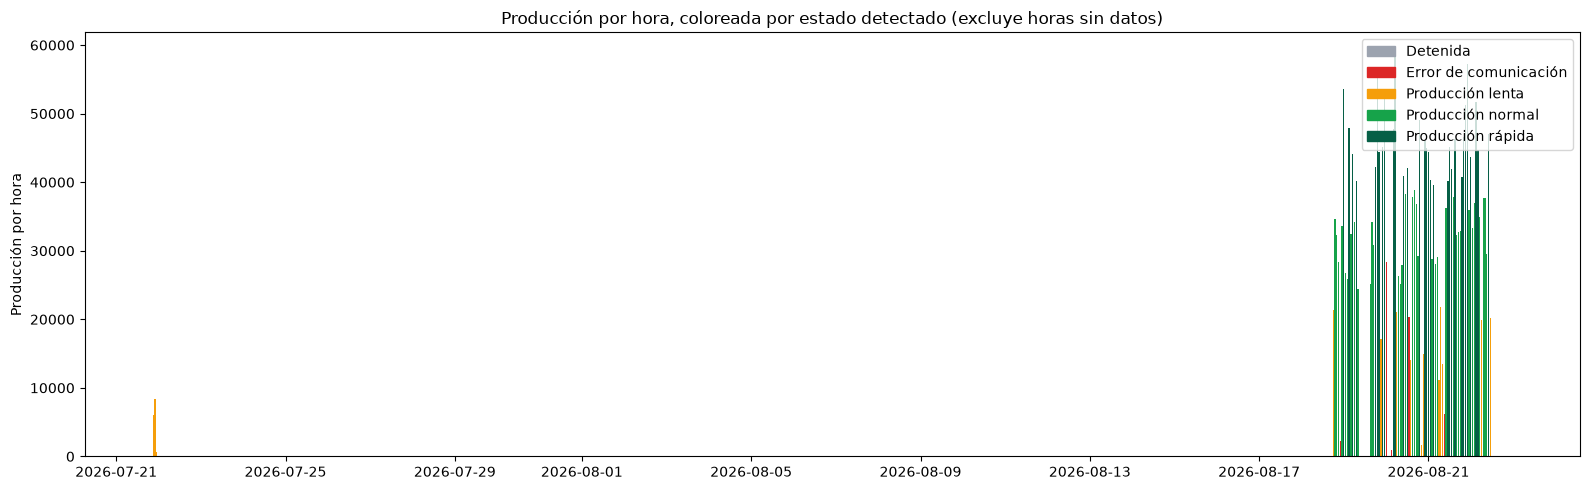

In [7]:
COLORS = {
    "sin_datos": "#e5e7eb", "detenida": "#9ca3af", "comm_error": "#dc2626",
    "produccion_lenta": "#f59e0b", "produccion_normal": "#16a34a", "produccion_rapida": "#065f46",
}
LABELS = {
    "sin_datos": "Sin datos", "detenida": "Detenida", "comm_error": "Error de comunicación",
    "produccion_lenta": "Producción lenta", "produccion_normal": "Producción normal", "produccion_rapida": "Producción rápida",
}
ORDER = list(COLORS.keys())

active = features_df[features_df["state"] != "sin_datos"]
fig, ax = plt.subplots(figsize=(16, 5))
for s in ORDER:
    if s == "sin_datos":
        continue
    sub = active[active["state"] == s]
    if not sub.empty:
        ax.bar(sub.index, sub["produccion_delta"], width=0.03, color=COLORS[s], label=LABELS[s])
ax.set_ylabel("Producción por hora")
ax.set_title("Producción por hora, coloreada por estado detectado (excluye horas sin datos)")
handles = [mpatches.Patch(color=COLORS[s], label=LABELS[s]) for s in ORDER if s != "sin_datos" and (features_df["state"] == s).any()]
ax.legend(handles=handles, loc="upper right")
fig.tight_layout()
plt.show()


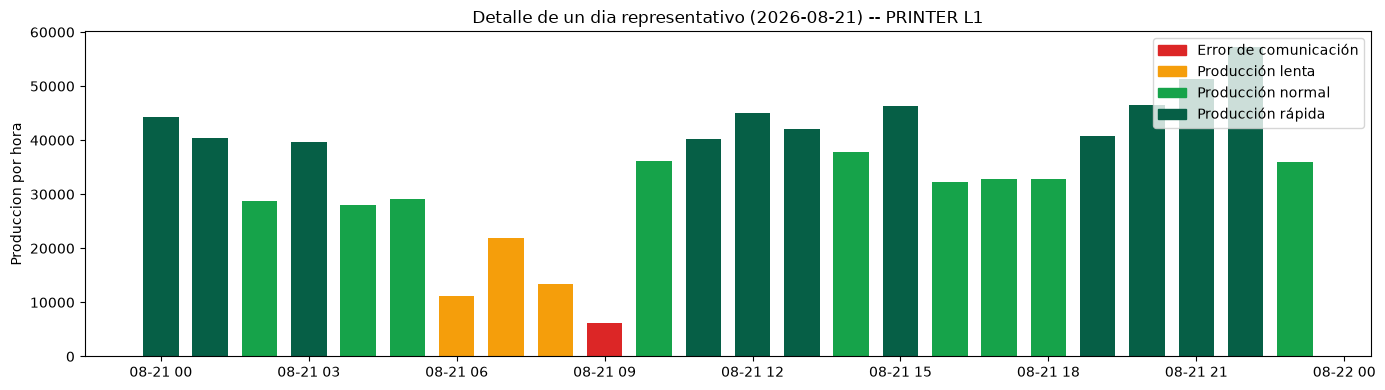

In [8]:
day_counts = active.groupby(active.index.date).size()
best_day = day_counts.idxmax()
day_df = features_df[features_df.index.date == best_day]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(day_df.index, day_df["produccion_delta"], width=0.03, color=[COLORS[s] for s in day_df["state"]])
ax.set_title(f"Detalle de un dia representativo ({best_day}) -- PRINTER L1")
ax.set_ylabel("Produccion por hora")
handles = [mpatches.Patch(color=COLORS[s], label=LABELS[s]) for s in ORDER if (day_df["state"] == s).any()]
ax.legend(handles=handles, loc="upper right")
fig.tight_layout()
plt.show()


C:\Users\sanch\AppData\Local\Temp\ipykernel_20768\3543551239.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  last_2_days = features_df.index.max().normalize() - pd.Timedelta(days=1)


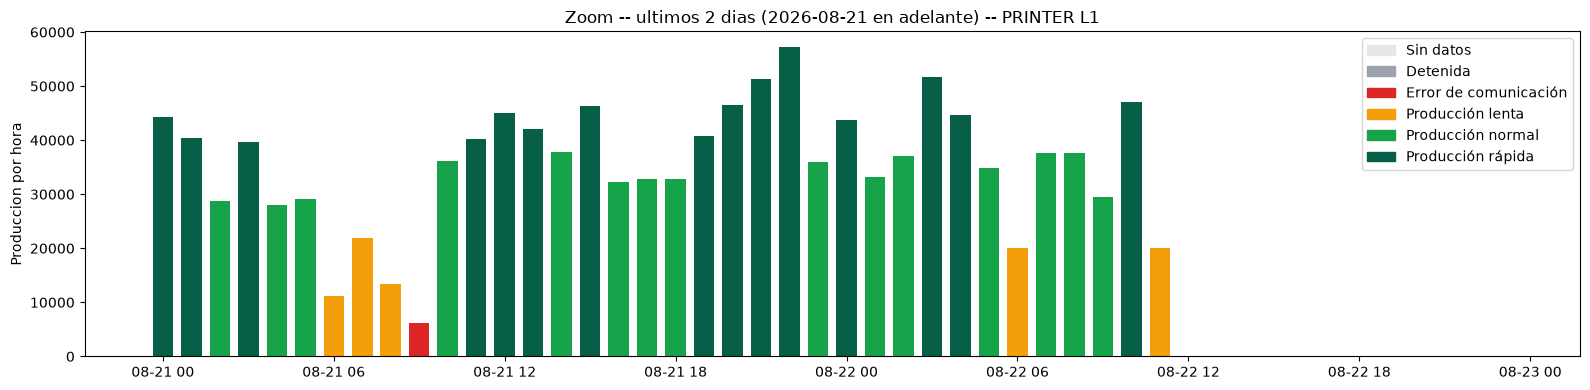

In [9]:
last_2_days = features_df.index.max().normalize() - pd.Timedelta(days=1)
zoom_df = features_df[features_df.index >= last_2_days]

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(zoom_df.index, zoom_df["produccion_delta"], width=0.03, color=[COLORS[s] for s in zoom_df["state"]])
ax.set_title(f"Zoom -- ultimos 2 dias ({last_2_days.date()} en adelante) -- PRINTER L1")
ax.set_ylabel("Produccion por hora")
handles = [mpatches.Patch(color=COLORS[s], label=LABELS[s]) for s in ORDER if (zoom_df["state"] == s).any()]
ax.legend(handles=handles, loc="upper right")
fig.tight_layout()
plt.show()


**Lectura del día 2026-08-21**: producción rápida/normal sostenida la mayor parte del día, una desaceleración gradual hacia `producción_lenta` entre 05:00-08:00, un `comm_error` puntual cerca de las 09:00, y luego retorno a producción normal/rápida. Es una historia físicamente coherente, no ruido -- buena señal de que el pipeline (reglas + clustering) está capturando algo real.

## 7. Próximos pasos

- **Extender a otras máquinas/tipos**: el pipeline de features y reglas es
  genérico; solo hace falta descargar los datos crudos de otra máquina y
  volver a correr.
- **Ground truth real**: si en algún momento se etiquetan manualmente
  algunas horas (ej. confirmando con el supervisor de producción qué pasó
  en una ventana específica), esas etiquetas + las features ya calculadas
  aquí permitirían entrenar un clasificador supervisado (Random Forest,
  por ejemplo) en vez de depender de clustering no supervisado.
- **Revisitar arrancando/deteniéndose**: la regla de asimetría entre mitades de hora no dio un resultado confiable y se retiró (ver sección 5) -- con más datos históricos, o a una granularidad más fina que la hora completa, podría intentarse de nuevo.
- **Afinar el `k` del clustering de velocidad** con más datos históricos, una vez que haya más horas activas acumuladas.
- **Integrar con `timeseries_anomaly_detector`**: los estados `comm_error`
  y `detenida` aquí calculados con el mismo criterio que ya usa esa
  función en producción -- podría ser una validación cruzada útil.
